In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import confusion_matrix, classification_report

In [2]:
data_folder = '/Users/muhammadtaha/Desktop/Computer Science Project by Muhammad Taha Iqbal/Dataset/Camel Dataset'

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    zoom_range=0.2,
    shear_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest',
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_folder,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    subset='training'
)

validation_generator = val_datagen.flow_from_directory(
    data_folder,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 806 images belonging to 4 classes.
Found 200 images belonging to 4 classes.


In [ ]:
VGG16

In [3]:
class_weights = None

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze MOST layers but not too many
for layer in base_model.layers[:-6]:
    layer.trainable = False

for layer in base_model.layers[-6:]:
    layer.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = BatchNormalization()(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)

output = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.0001),   
    loss='categorical_crossentropy',        
    metrics=['accuracy']
)


In [4]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

In [5]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=40,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights
)

Epoch 1/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5089 - loss: 1.2049

/opt/anaconda3/envs/LiveStock-HealthMangmentSystem/lib/python3.11/site-packages/PIL/Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


51/51 ━━━━━━━━━━━━━━━━━━━━ 125s 2s/step - accuracy: 0.6551 - loss: 0.8737 - val_accuracy: 0.8950 - val_loss: 0.3943 - learning_rate: 1.0000e-04
Epoch 2/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 124s 2s/step - accuracy: 0.8635 - loss: 0.4332 - val_accuracy: 0.9250 - val_loss: 0.2557 - learning_rate: 1.0000e-04
Epoch 3/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 124s 2s/step - accuracy: 0.8660 - loss: 0.3768 - val_accuracy: 0.8950 - val_loss: 0.4333 - learning_rate: 1.0000e-04
Epoch 4/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 125s 2s/step - accuracy: 0.8921 - loss: 0.3144 - val_accuracy: 0.9650 - val_loss: 0.1845 - learning_rate: 1.0000e-04
Epoch 5/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 127s 2s/step - accuracy: 0.9268 - loss: 0.2368 - val_accuracy: 0.9100 - val_loss: 0.3143 - learning_rate: 1.0000e-04
Epoch 6/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 127s 2s/step - accuracy: 0.9293 - loss: 0.2243 - val_accuracy: 0.8450 - val_loss: 0.6963 - learning_rate: 1.0000e-04
Epoch 7/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 127s 2s/step - accuracy: 0.9169 - loss: 0.2

In [6]:
loss, accuracy = model.evaluate(validation_generator)
print("Validation Accuracy:", accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.9650 - loss: 0.1276
Validation Accuracy: 0.9649999737739563


13/13 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step


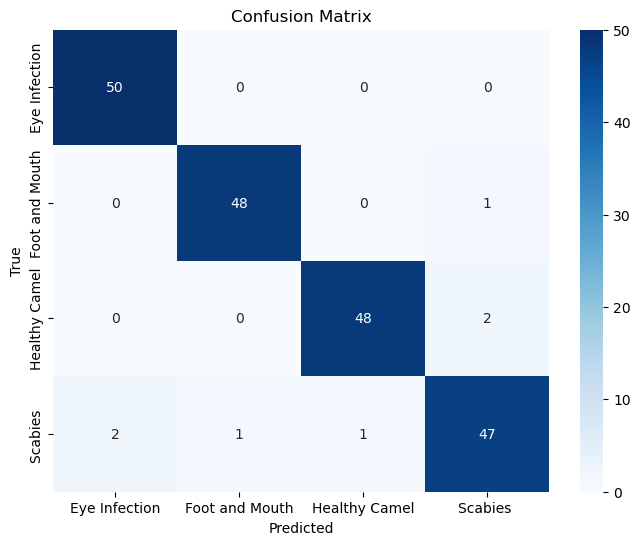

                precision    recall  f1-score   support

 Eye Infection       0.96      1.00      0.98        50
Foot and Mouth       0.98      0.98      0.98        49
 Healthy Camel       0.98      0.96      0.97        50
      Scabies        0.94      0.92      0.93        51

      accuracy                           0.96       200
     macro avg       0.97      0.97      0.97       200
  weighted avg       0.96      0.96      0.96       200



In [7]:
validation_generator.reset()

predictions = model.predict(validation_generator)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = validation_generator.classes

confusion_mtx = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8,6))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='Blues',
            xticklabels=validation_generator.class_indices.keys(),
            yticklabels=validation_generator.class_indices.keys())

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=validation_generator.class_indices.keys()
))

In [8]:
metrics_dict = {}
class_names = list(validation_generator.class_indices.keys())

for i, class_name in enumerate(class_names):
    TP = confusion_mtx[i, i]
    FP = confusion_mtx[:, i].sum() - TP
    FN = confusion_mtx[i, :].sum() - TP
    TN = confusion_mtx.sum() - (TP + FP + FN)
    
    metrics_dict[class_name] = {
        'TP': TP,
        'FP': FP,
        'FN': FN,
        'TN': TN
    }

metrics_df = pd.DataFrame(metrics_dict).T

print(metrics_df)

                TP  FP  FN   TN
Eye Infection   50   2   0  148
Foot and Mouth  48   1   1  150
Healthy Camel   48   1   2  149
Scabies         47   3   4  146


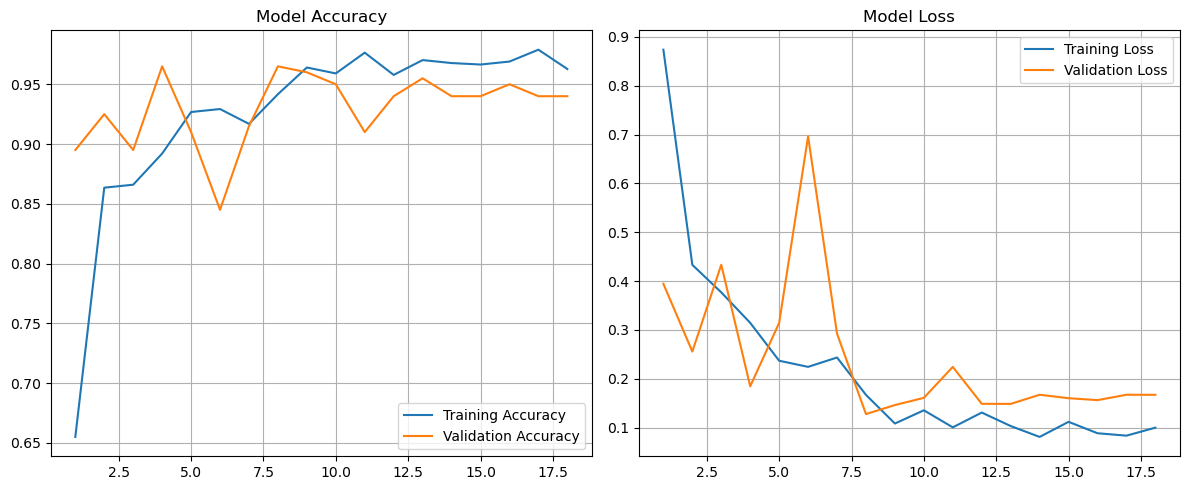

In [9]:
training_accuracy = history.history['accuracy']
validation_accuracy = history.history['val_accuracy']
training_loss = history.history['loss']
validation_loss = history.history['val_loss']

epochs_range = range(1, len(training_accuracy) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, training_accuracy, label='Training Accuracy')
plt.plot(epochs_range, validation_accuracy, label='Validation Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, training_loss, label='Training Loss')
plt.plot(epochs_range, validation_loss, label='Validation Loss')
plt.title('Model Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [10]:
model.save('AImodel_VGG16_Camel.keras')

In [11]:
model.save('AImodel_VGG16_Camel.h5')

In [ ]:
ResNet50

In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import confusion_matrix, classification_report

In [14]:
data_folder = '/Users/muhammadtaha/Desktop/Computer Science Project by Muhammad Taha Iqbal/Dataset/Camel Dataset'

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    zoom_range=0.2,
    shear_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest',
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_folder,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    subset='training'
)

validation_generator = val_datagen.flow_from_directory(
    data_folder,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 806 images belonging to 4 classes.
Found 200 images belonging to 4 classes.


In [15]:
class_weights = None

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze most layers
for layer in base_model.layers[:-15]:
    layer.trainable = False

for layer in base_model.layers[-15:]:
    layer.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = BatchNormalization()(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)

output = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [16]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

In [17]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=40,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights
)

Epoch 1/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 587ms/step - accuracy: 0.4782 - loss: 1.4666

/opt/anaconda3/envs/LiveStock-HealthMangmentSystem/lib/python3.11/site-packages/PIL/Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


51/51 ━━━━━━━━━━━━━━━━━━━━ 44s 738ms/step - accuracy: 0.6203 - loss: 1.0414 - val_accuracy: 0.8450 - val_loss: 0.4108 - learning_rate: 1.0000e-04
Epoch 2/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 36s 700ms/step - accuracy: 0.8511 - loss: 0.4677 - val_accuracy: 0.9250 - val_loss: 0.2395 - learning_rate: 1.0000e-04
Epoch 3/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 36s 707ms/step - accuracy: 0.8908 - loss: 0.3229 - val_accuracy: 0.9250 - val_loss: 0.2248 - learning_rate: 1.0000e-04
Epoch 4/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 36s 710ms/step - accuracy: 0.9194 - loss: 0.2388 - val_accuracy: 0.9350 - val_loss: 0.2178 - learning_rate: 1.0000e-04
Epoch 5/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 36s 701ms/step - accuracy: 0.9256 - loss: 0.2225 - val_accuracy: 0.9350 - val_loss: 0.1924 - learning_rate: 1.0000e-04
Epoch 6/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 37s 731ms/step - accuracy: 0.9417 - loss: 0.1546 - val_accuracy: 0.9600 - val_loss: 0.1695 - learning_rate: 1.0000e-04
Epoch 7/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 37s 726ms/step - accuracy: 0.95

In [18]:
loss, accuracy = model.evaluate(validation_generator)
print("Validation Accuracy:", accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 460ms/step - accuracy: 0.9600 - loss: 0.1695
Validation Accuracy: 0.9599999785423279


13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 538ms/step


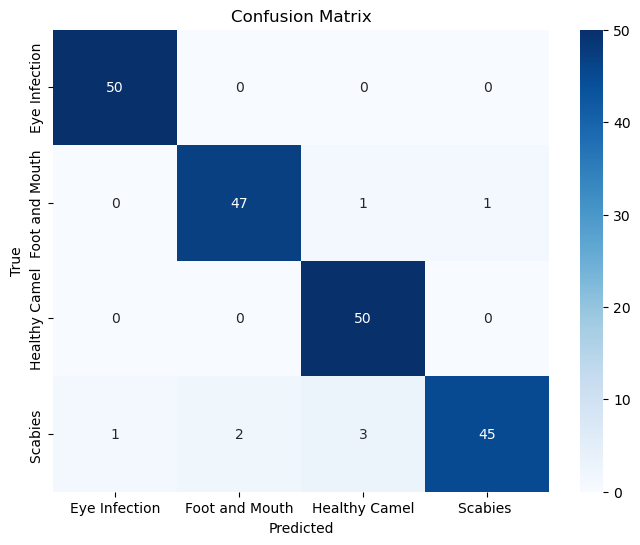

                precision    recall  f1-score   support

 Eye Infection       0.98      1.00      0.99        50
Foot and Mouth       0.96      0.96      0.96        49
 Healthy Camel       0.93      1.00      0.96        50
      Scabies        0.98      0.88      0.93        51

      accuracy                           0.96       200
     macro avg       0.96      0.96      0.96       200
  weighted avg       0.96      0.96      0.96       200



In [19]:
validation_generator.reset()

predictions = model.predict(validation_generator)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = validation_generator.classes

confusion_mtx = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8,6))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='Blues',
            xticklabels=validation_generator.class_indices.keys(),
            yticklabels=validation_generator.class_indices.keys())

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=validation_generator.class_indices.keys()
))

In [20]:
metrics_dict = {}
class_names = list(validation_generator.class_indices.keys())

for i, class_name in enumerate(class_names):
    TP = confusion_mtx[i, i]
    FP = confusion_mtx[:, i].sum() - TP
    FN = confusion_mtx[i, :].sum() - TP
    TN = confusion_mtx.sum() - (TP + FP + FN)
    
    metrics_dict[class_name] = {
        'TP': TP,
        'FP': FP,
        'FN': FN,
        'TN': TN
    }

metrics_df = pd.DataFrame(metrics_dict).T
print(metrics_df)

                TP  FP  FN   TN
Eye Infection   50   1   0  149
Foot and Mouth  47   2   2  149
Healthy Camel   50   4   0  146
Scabies         45   1   6  148


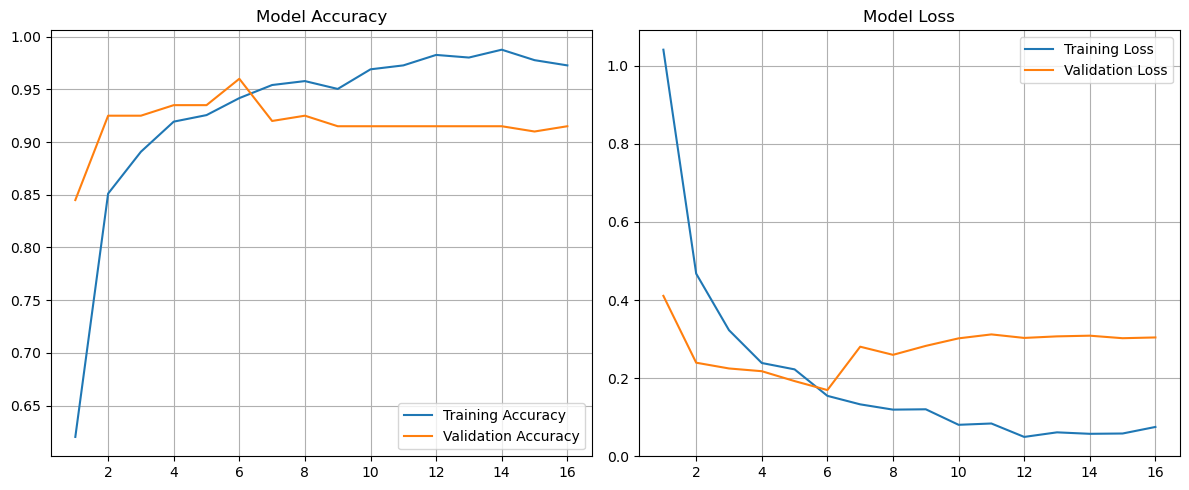

In [21]:
training_accuracy = history.history['accuracy']
validation_accuracy = history.history['val_accuracy']
training_loss = history.history['loss']
validation_loss = history.history['val_loss']

epochs_range = range(1, len(training_accuracy) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, training_accuracy, label='Training Accuracy')
plt.plot(epochs_range, validation_accuracy, label='Validation Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, training_loss, label='Training Loss')
plt.plot(epochs_range, validation_loss, label='Validation Loss')
plt.title('Model Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [22]:
model.save('AImodel_ResNet50_Camel.keras')

In [ ]:
DenseNet121

In [23]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import confusion_matrix, classification_report

In [24]:
data_folder = '/Users/muhammadtaha/Desktop/Computer Science Project by Muhammad Taha Iqbal/Dataset/Camel Dataset'

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    zoom_range=0.2,
    shear_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest',
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_folder,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    subset='training'
)

validation_generator = val_datagen.flow_from_directory(
    data_folder,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 806 images belonging to 4 classes.
Found 200 images belonging to 4 classes.


In [25]:
class_weights = None

base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze most layers but allow deeper learning
for layer in base_model.layers[:-20]:
    layer.trainable = False

for layer in base_model.layers[-20:]:
    layer.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = BatchNormalization()(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)

output = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [26]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

In [27]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=40,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights
)

Epoch 1/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 538ms/step - accuracy: 0.3785 - loss: 1.5073

/opt/anaconda3/envs/LiveStock-HealthMangmentSystem/lib/python3.11/site-packages/PIL/Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


51/51 ━━━━━━━━━━━━━━━━━━━━ 47s 730ms/step - accuracy: 0.4739 - loss: 1.2789 - val_accuracy: 0.8150 - val_loss: 0.8096 - learning_rate: 1.0000e-04
Epoch 2/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 34s 662ms/step - accuracy: 0.7097 - loss: 0.7947 - val_accuracy: 0.8500 - val_loss: 0.5583 - learning_rate: 1.0000e-04
Epoch 3/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 33s 642ms/step - accuracy: 0.7866 - loss: 0.5984 - val_accuracy: 0.8650 - val_loss: 0.4332 - learning_rate: 1.0000e-04
Epoch 4/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 34s 657ms/step - accuracy: 0.8139 - loss: 0.5191 - val_accuracy: 0.8700 - val_loss: 0.3745 - learning_rate: 1.0000e-04
Epoch 5/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 32s 634ms/step - accuracy: 0.8524 - loss: 0.4492 - val_accuracy: 0.8800 - val_loss: 0.3279 - learning_rate: 1.0000e-04
Epoch 6/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 33s 655ms/step - accuracy: 0.8548 - loss: 0.4028 - val_accuracy: 0.8850 - val_loss: 0.3021 - learning_rate: 1.0000e-04
Epoch 7/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 33s 648ms/step - accuracy: 0.88

In [28]:
loss, accuracy = model.evaluate(validation_generator)
print("Validation Accuracy:", accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 481ms/step - accuracy: 0.9450 - loss: 0.1673
Validation Accuracy: 0.9449999928474426


13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 648ms/step


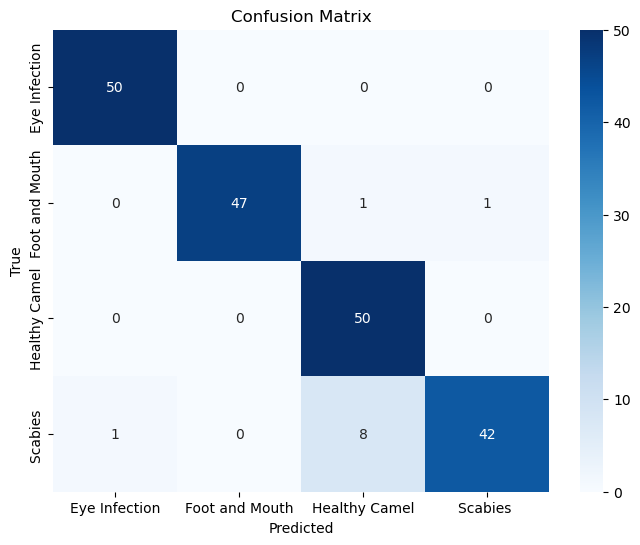

                precision    recall  f1-score   support

 Eye Infection       0.98      1.00      0.99        50
Foot and Mouth       1.00      0.96      0.98        49
 Healthy Camel       0.85      1.00      0.92        50
      Scabies        0.98      0.82      0.89        51

      accuracy                           0.94       200
     macro avg       0.95      0.95      0.95       200
  weighted avg       0.95      0.94      0.94       200



In [29]:
validation_generator.reset()

predictions = model.predict(validation_generator)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = validation_generator.classes

confusion_mtx = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8,6))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='Blues',
            xticklabels=validation_generator.class_indices.keys(),
            yticklabels=validation_generator.class_indices.keys())

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=validation_generator.class_indices.keys()
))

In [30]:
metrics_dict = {}
class_names = list(validation_generator.class_indices.keys())

for i, class_name in enumerate(class_names):
    TP = confusion_mtx[i, i]
    FP = confusion_mtx[:, i].sum() - TP
    FN = confusion_mtx[i, :].sum() - TP
    TN = confusion_mtx.sum() - (TP + FP + FN)
    
    metrics_dict[class_name] = {
        'TP': TP,
        'FP': FP,
        'FN': FN,
        'TN': TN
    }

metrics_df = pd.DataFrame(metrics_dict).T
print(metrics_df)

                TP  FP  FN   TN
Eye Infection   50   1   0  149
Foot and Mouth  47   0   2  151
Healthy Camel   50   9   0  141
Scabies         42   1   9  148


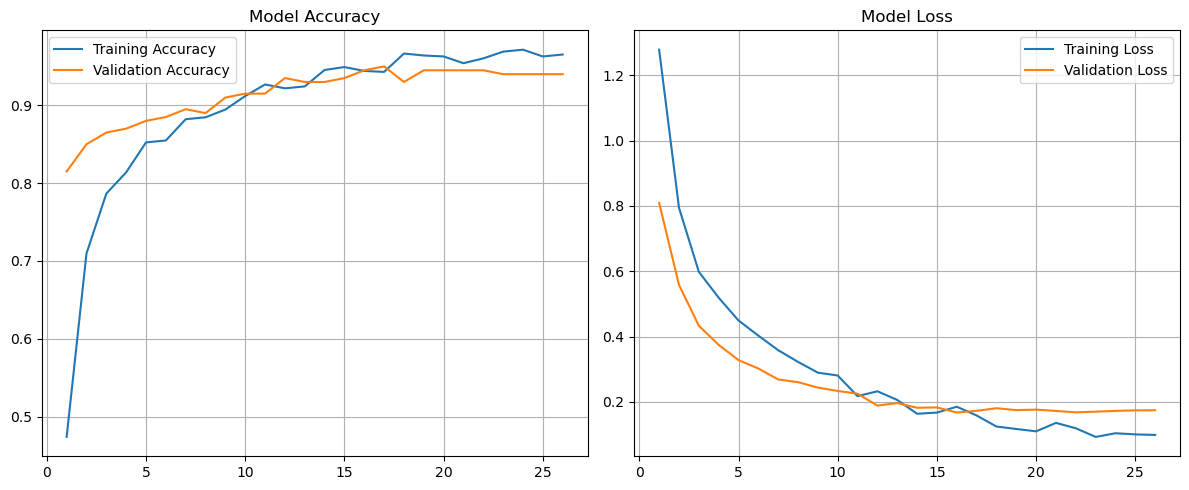

In [31]:
training_accuracy = history.history['accuracy']
validation_accuracy = history.history['val_accuracy']
training_loss = history.history['loss']
validation_loss = history.history['val_loss']

epochs_range = range(1, len(training_accuracy) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, training_accuracy, label='Training Accuracy')
plt.plot(epochs_range, validation_accuracy, label='Validation Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, training_loss, label='Training Loss')
plt.plot(epochs_range, validation_loss, label='Validation Loss')
plt.title('Model Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [32]:
model.save('AImodel_DenseNet121_Camel.keras')

In [ ]:
MobileNetV2 

In [33]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import confusion_matrix, classification_report

In [34]:
data_folder = '/Users/muhammadtaha/Desktop/Computer Science Project by Muhammad Taha Iqbal/Dataset/Camel Dataset'

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    zoom_range=0.2,
    shear_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest',
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_folder,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    subset='training'
)

validation_generator = val_datagen.flow_from_directory(
    data_folder,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 806 images belonging to 4 classes.
Found 200 images belonging to 4 classes.


In [35]:
class_weights = None

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze most layers; fine-tune last 50 layers for small dataset
for layer in base_model.layers[:-50]:
    layer.trainable = False

for layer in base_model.layers[-50:]:
    layer.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)

output = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [37]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

In [38]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=40,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights
)

Epoch 1/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 0.3795 - loss: 1.6712

/opt/anaconda3/envs/LiveStock-HealthMangmentSystem/lib/python3.11/site-packages/PIL/Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


51/51 ━━━━━━━━━━━━━━━━━━━━ 23s 299ms/step - accuracy: 0.5298 - loss: 1.1971 - val_accuracy: 0.6500 - val_loss: 0.7745 - learning_rate: 1.0000e-04
Epoch 2/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 14s 266ms/step - accuracy: 0.8164 - loss: 0.5131 - val_accuracy: 0.8350 - val_loss: 0.4447 - learning_rate: 1.0000e-04
Epoch 3/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 14s 270ms/step - accuracy: 0.8660 - loss: 0.3968 - val_accuracy: 0.8800 - val_loss: 0.3669 - learning_rate: 1.0000e-04
Epoch 4/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 14s 266ms/step - accuracy: 0.8958 - loss: 0.3081 - val_accuracy: 0.8900 - val_loss: 0.3784 - learning_rate: 1.0000e-04
Epoch 5/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 14s 268ms/step - accuracy: 0.9107 - loss: 0.2561 - val_accuracy: 0.9050 - val_loss: 0.3785 - learning_rate: 1.0000e-04
Epoch 6/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 14s 267ms/step - accuracy: 0.9293 - loss: 0.2048 - val_accuracy: 0.9100 - val_loss: 0.3452 - learning_rate: 1.0000e-04
Epoch 7/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 14s 268ms/step - accuracy: 0.93

In [39]:
loss, accuracy = model.evaluate(validation_generator)
print("Validation Accuracy:", accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 132ms/step - accuracy: 0.9250 - loss: 0.2670
Validation Accuracy: 0.925000011920929


13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 187ms/step


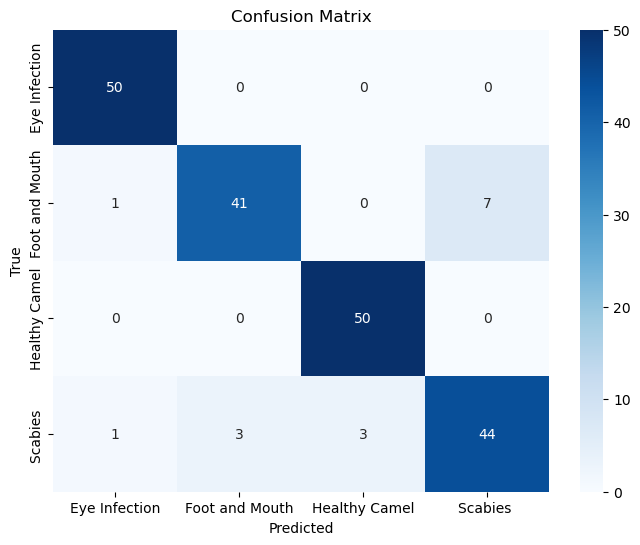

                precision    recall  f1-score   support

 Eye Infection       0.96      1.00      0.98        50
Foot and Mouth       0.93      0.84      0.88        49
 Healthy Camel       0.94      1.00      0.97        50
      Scabies        0.86      0.86      0.86        51

      accuracy                           0.93       200
     macro avg       0.92      0.92      0.92       200
  weighted avg       0.92      0.93      0.92       200



In [40]:
validation_generator.reset()

predictions = model.predict(validation_generator)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = validation_generator.classes

confusion_mtx = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8,6))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='Blues',
            xticklabels=validation_generator.class_indices.keys(),
            yticklabels=validation_generator.class_indices.keys())

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=validation_generator.class_indices.keys()
))

In [41]:
metrics_dict = {}
class_names = list(validation_generator.class_indices.keys())

for i, class_name in enumerate(class_names):
    TP = confusion_mtx[i, i]
    FP = confusion_mtx[:, i].sum() - TP
    FN = confusion_mtx[i, :].sum() - TP
    TN = confusion_mtx.sum() - (TP + FP + FN)
    
    metrics_dict[class_name] = {
        'TP': TP,
        'FP': FP,
        'FN': FN,
        'TN': TN
    }

metrics_df = pd.DataFrame(metrics_dict).T
print(metrics_df)

                TP  FP  FN   TN
Eye Infection   50   2   0  148
Foot and Mouth  41   3   8  148
Healthy Camel   50   3   0  147
Scabies         44   7   7  142


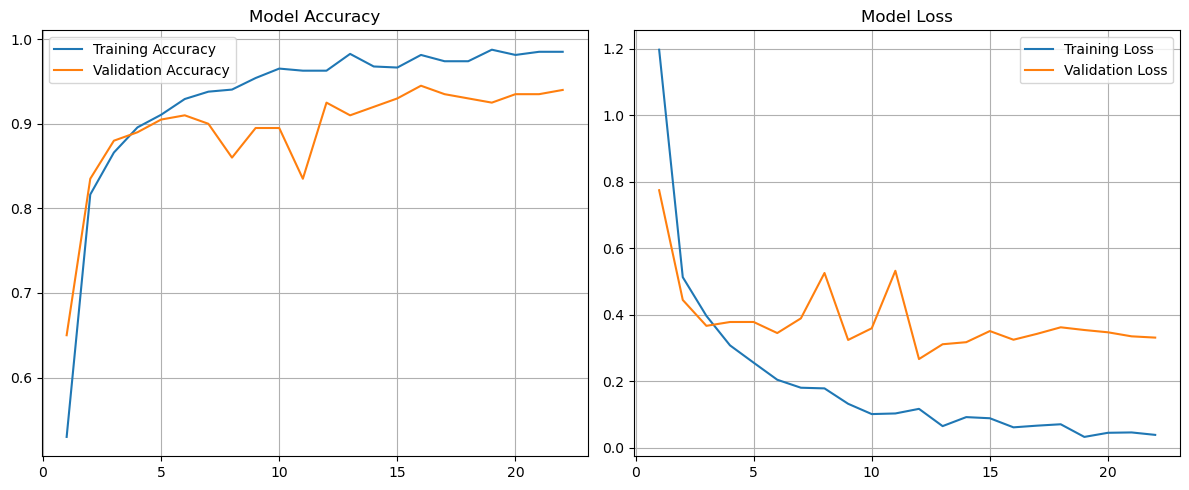

In [42]:
training_accuracy = history.history['accuracy']
validation_accuracy = history.history['val_accuracy']
training_loss = history.history['loss']
validation_loss = history.history['val_loss']

epochs_range = range(1, len(training_accuracy) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, training_accuracy, label='Training Accuracy')
plt.plot(epochs_range, validation_accuracy, label='Validation Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, training_loss, label='Training Loss')
plt.plot(epochs_range, validation_loss, label='Validation Loss')
plt.title('Model Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [43]:
model.save('AImodel_MobileNetV2_Camel.keras')                                                                

In [ ]:
Vision Transformer (ViT)

In [44]:
!pip install vit-keras
!pip install tensorflow-addons

In [46]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Flatten, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from vit_keras import vit
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

In [47]:
data_folder = '/Users/muhammadtaha/Desktop/Computer Science Project by Muhammad Taha Iqbal/Dataset/Camel Dataset'

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.15,
    horizontal_flip=True,
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_folder,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    subset='training'
)

validation_generator = val_datagen.flow_from_directory(
    data_folder,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 806 images belonging to 4 classes.
Found 200 images belonging to 4 classes.


In [48]:
classes = train_generator.classes

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(classes),
    y=classes
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(1.0024875621890548), 1: np.float64(1.0125628140703518), 2: np.float64(1.0075), 3: np.float64(0.9781553398058253)}


In [49]:
vit_model = vit.vit_b16(
    image_size=224,
    pretrained=True,
    include_top=False,
    pretrained_top=False
)

# Freeze most layers, fine-tune last 15
for layer in vit_model.layers[:-15]:
    layer.trainable = False

for layer in vit_model.layers[-15:]:
    layer.trainable = True

x = vit_model.output
x = Flatten()(x)
x = BatchNormalization()(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.4)(x)

output = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=vit_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.00003),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

/opt/anaconda3/envs/LiveStock-HealthMangmentSystem/lib/python3.11/site-packages/vit_keras/utils.py:85: UserWarning: Resizing position embeddings from 24, 24 to 14, 14
  warnings.warn(


In [50]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

In [51]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=40,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights
)

Epoch 1/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.3384 - loss: 1.9920

/opt/anaconda3/envs/LiveStock-HealthMangmentSystem/lib/python3.11/site-packages/PIL/Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


51/51 ━━━━━━━━━━━━━━━━━━━━ 471s 9s/step - accuracy: 0.4429 - loss: 1.6708 - val_accuracy: 0.7900 - val_loss: 0.7881 - learning_rate: 3.0000e-05
Epoch 2/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 442s 9s/step - accuracy: 0.6551 - loss: 1.1171 - val_accuracy: 0.9050 - val_loss: 0.5956 - learning_rate: 3.0000e-05
Epoch 3/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 442s 9s/step - accuracy: 0.7407 - loss: 0.9651 - val_accuracy: 0.9250 - val_loss: 0.5375 - learning_rate: 3.0000e-05
Epoch 4/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 442s 9s/step - accuracy: 0.8201 - loss: 0.7981 - val_accuracy: 0.8950 - val_loss: 0.5687 - learning_rate: 3.0000e-05
Epoch 5/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 442s 9s/step - accuracy: 0.8400 - loss: 0.7587 - val_accuracy: 0.9200 - val_loss: 0.5303 - learning_rate: 3.0000e-05
Epoch 6/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 443s 9s/step - accuracy: 0.8300 - loss: 0.7490 - val_accuracy: 0.9300 - val_loss: 0.5339 - learning_rate: 3.0000e-05
Epoch 7/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 444s 9s/step - accuracy: 0.8784 - loss: 0.6

In [52]:
loss, accuracy = model.evaluate(validation_generator)
print("Validation Accuracy:", accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 35s 3s/step - accuracy: 0.9500 - loss: 0.5052
Validation Accuracy: 0.949999988079071


13/13 ━━━━━━━━━━━━━━━━━━━━ 37s 3s/step


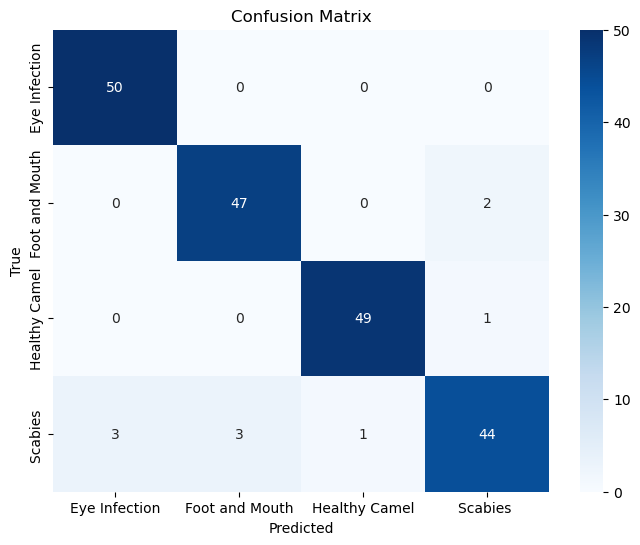

                precision    recall  f1-score   support

 Eye Infection       0.94      1.00      0.97        50
Foot and Mouth       0.94      0.96      0.95        49
 Healthy Camel       0.98      0.98      0.98        50
      Scabies        0.94      0.86      0.90        51

      accuracy                           0.95       200
     macro avg       0.95      0.95      0.95       200
  weighted avg       0.95      0.95      0.95       200



In [53]:
validation_generator.reset()

predictions = model.predict(validation_generator)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = validation_generator.classes

confusion_mtx = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8,6))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='Blues',
            xticklabels=validation_generator.class_indices.keys(),
            yticklabels=validation_generator.class_indices.keys())

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=validation_generator.class_indices.keys()
))

In [54]:
metrics_dict = {}
class_names = list(validation_generator.class_indices.keys())

for i, class_name in enumerate(class_names):
    TP = confusion_mtx[i, i]
    FP = confusion_mtx[:, i].sum() - TP
    FN = confusion_mtx[i, :].sum() - TP
    TN = confusion_mtx.sum() - (TP + FP + FN)
    
    metrics_dict[class_name] = {
        'TP': TP,
        'FP': FP,
        'FN': FN,
        'TN': TN
    }

metrics_df = pd.DataFrame(metrics_dict).T
print(metrics_df)

                TP  FP  FN   TN
Eye Infection   50   3   0  147
Foot and Mouth  47   3   2  148
Healthy Camel   49   1   1  149
Scabies         44   3   7  146


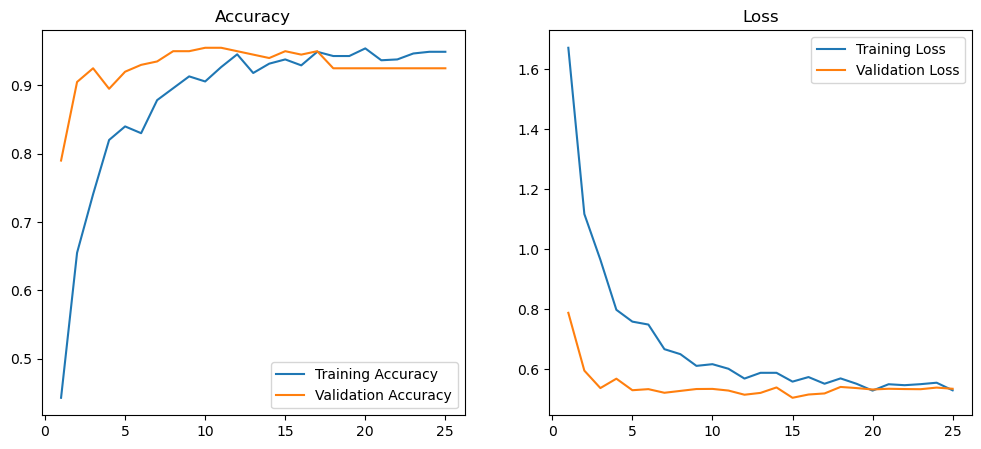

In [55]:
training_accuracy = history.history['accuracy']
validation_accuracy = history.history['val_accuracy']
training_loss = history.history['loss']
validation_loss = history.history['val_loss']

epochs_range = range(1, len(training_accuracy) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, training_accuracy, label='Training Accuracy')
plt.plot(epochs_range, validation_accuracy, label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, training_loss, label='Training Loss')
plt.plot(epochs_range, validation_loss, label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.show()

In [56]:
model.save('AImodel_ViT_Camel.keras')